# Tutorial 4, Kernels 

In [33]:
from PIL import Image, ImageDraw, ImageFilter
import numpy as np
from numpy.polynomial.chebyshev import chebvander
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors

from matplotlib.ticker import LinearLocator
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import Image as IMG
from IPython.display import display
import imageio
import os

#supresses showing plots, instead load generated png files
matplotlib.use('Agg')

#　Default generates plots in dark mode
plt.style.use('dark_background') 
nice_green = (0.3,0.6,0.1)
nice_cyan = (0,0.8,0.6)
# nice_blue = (0.3,0.4,1)
nice_blue = (0.3,0.8,1) # better contrast 
nice_purple = (1,0.1,1)
nice_red = (0.8,0,0.1)
nice_yellow = (1,0.7,0)
nice_orange = (1,0.5,0)
off_white = (1,0.9,1)
off_black = (0.2,0.2,0.2)
black = (0,0,0)

In [2]:
#Run this cell if you want the plots in light mode
plt.style.use('default')
nice_cyan = (0.1,1,0.9)
nice_blue = (0.3,0.8,1)
nice_purple = (1,0.3,1)
nice_red = (0.9,0,0.1)
nice_yellow = (1,0.8,0.2)
nice_orange = (1,0.6,0.1)
off_white = (1,0.9,1)

Functions for plotting and styling

In [3]:
# this loads all images from a given directory and returns a collage of them
def create_collage(image_dir, rows, cols, shrink=1, output_path='collage.jpg'):
    valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.gif', '.tiff')

    image_files = [
        f for f in os.listdir(image_dir)
        if os.path.isfile(os.path.join(image_dir, f))
        and f.lower().endswith(valid_exts)
    ]

    if not image_files:
        raise ValueError("No valid image files found in the directory.")

    first_image = Image.open(os.path.join(image_dir, image_files[0]))
    cell_w, cell_h = first_image.size

    collage_w = cell_w * cols
    collage_h = cell_h * rows
    collage = Image.new('RGB', (collage_w, collage_h))

    x_offset = 0
    y_offset = 0

    image_files.sort()

    for i, image_file in enumerate(image_files):
        img_path = os.path.join(image_dir, image_file)
        img = Image.open(img_path)
        img = img.resize((cell_w, cell_h))

        collage.paste(img, (x_offset, y_offset))
        x_offset += cell_w

        if (i + 1) % cols == 0:
            x_offset = 0
            y_offset += cell_h

        if y_offset >= collage_h:
            break

    if shrink > 1:
        new_w = int(collage_w / shrink)
        new_h = int(collage_h / shrink)
        collage = collage.resize((new_w, new_h))

    collage.save(output_path)
    return collage

In [4]:
def plot_function_and_datapoints(X,Y, X_measured, Y_measured,title,folder):
    plt.figure(figsize=(8, 6))

    plt.plot(X,Y, color = nice_cyan, linewidth = 5,zorder=1)
    plt.plot(X,Y, color = nice_blue, linewidth = 2,zorder=1, label=" Underlying function ")

    plt.scatter(X_measured,Y_measured, s = 60, color = nice_blue,  label="Measurement", zorder=2)
    fsize = 18
    plt.xlim(-10,10)
    plt.ylim(-10,10)
    plt.rc('text', usetex=True)
    plt.xlabel("$x$", fontsize = 18, rotation = 0)
    plt.ylabel("$y$", fontsize = 18, rotation = 0)
    plt.xticks([-10,-5,0,5,10], fontsize = 14)
    plt.yticks([-10,-5,0,5,10], fontsize = 14)
    plt.legend(loc= "upper right", fontsize = fsize)
    plt.title(title, fontsize = 20)
    plt.grid(color=(0.2,0.2,0.2), linestyle='--', linewidth=0.7, zorder = 1)
    plt.savefig(folder)

In [5]:
def plot_function_and_prediction_and_datapoints(X,Y, X_measured, Y_measured,X_prediction, Y_prediction,title,folder):
    # Clear figure
    plt.figure(figsize=(8, 6))

    # Function 1
    plt.plot(X,Y, color = nice_blue, linewidth = 5,zorder=1)
    plt.plot(X,Y, color = nice_blue, linewidth = 2,zorder=1, label=" Underlying function ")

    # Function 2
    plt.plot(X_prediction,Y_prediction, color = nice_red, linewidth = 5,zorder=1)
    plt.plot(X_prediction,Y_prediction, color = nice_purple, linewidth = 2,zorder=1, label="Predicted function ")

    # Dataset
    plt.scatter(X_measured,Y_measured, s = 60, color = nice_blue,  label="Measurement", zorder=2)

    # Layout and visuals
    fsize = 18
    plt.xlim(-10,10)
    plt.ylim(-10,10)
    plt.rc('text', usetex=True)
    plt.xlabel("$x$", fontsize = 20, rotation = 0)
    plt.ylabel("$y$", fontsize = 20, rotation = 0)
    plt.xticks([-10,-5,0,5,10], fontsize = 14)
    plt.yticks([-10,-5,0,5,10], fontsize = 14)
    #plt.legend(loc= "upper right", fontsize = fsize)
    plt.title(title, fontsize = 20)
    plt.grid(color=(0.2,0.2,0.2), linestyle='--', linewidth=0.7, zorder = 1)
    plt.savefig(folder)

Mapping function phi maps data into different spaces( where the problem can becomes easier to solve)

In [6]:
def plot_datapoints(X_measured, Y_measured,title,folder):
    plt.figure(figsize=(8, 6))

    plt.scatter(X_measured,Y_measured, s = 60, color = nice_blue,  label="Measurement", zorder=2)
    fsize = 18
    plt.xlim(-10,10)
    plt.ylim(-10,10)
    plt.rc('text', usetex=True)
    plt.xlabel("$x$", fontsize = 18, rotation = 0)
    plt.ylabel("$y$", fontsize = 18, rotation = 0)
    plt.xticks([-10,-5,0,5,10], fontsize = 14)
    plt.yticks([-5,0,5,10], fontsize = 14)
    plt.legend(loc= "upper right", fontsize = fsize)
    plt.title(title, fontsize = 20)
    plt.grid(color=(0.2,0.2,0.2), linestyle='--', linewidth=0.7, zorder = 1)
    plt.savefig(folder)

In [7]:
def plot_1d_scatter(A, B, folder):
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    plt.rcParams['text.usetex'] = True
    plt.rc('text', usetex=True)

    plt.figure(figsize=(8, 3))
    gen_nA = A.shape[0]
    plt.scatter(A,  np.zeros(gen_nA), color = nice_blue,label = "A")
    gen_nB = B.shape[0]
    plt.scatter(B,  np.zeros(gen_nB), color = nice_yellow, marker="*", label = "A")
    plt.title(f"Data in 1D that is not linearly separable in inputspace",fontsize = 20)
    plt.xticks([-10,-5,0,5,10], fontsize = 14)
    plt.yticks([-0.5,0.5], fontsize = 14)
    plt.xlabel(r"$x_1$", fontsize = 18)
    plt.grid(color=(0.2,0.2,0.2), linestyle='--', linewidth=0.7, zorder = 1)
    plt.yticks([]) 
    plt.legend(loc= "upper right", fontsize = 14)
    plt.savefig(folder)

In [8]:
def plot_two_scatter(A,B,title,folder):
    plt.figure(figsize=(8, 8))
    # get x1 and x2 values from A and B
    A_x1 = A[:,0]
    A_x2 = A[:,1]
    B_x1 = B[:,0]
    B_x2 = B[:,1]

    # Plot Data points from A and B
    plt.style.use('dark_background') #dark mode
    fsize = 18
    plt.xlim(-10,10)
    plt.ylim(-10,10)
    plt.rc('text', usetex=True)
    plt.xlabel("$x_1$", fontsize = 18, rotation = 0)
    plt.ylabel("$x_2$", fontsize = 18, rotation = 0)
    plt.xticks([-10,-5,0,5,10], fontsize = 14)
    plt.yticks([-10,-5,0,5,10], fontsize = 14)

    plt.title(title,  fontsize = 20)
    plt.grid(color=(0.2,0.2,0.2), linestyle='--', linewidth=0.7)

    # Plot Data points from A and B
    plt.scatter(A_x1,A_x2, s = 60, color = (0.2,0.4,1),  label="A")
    plt.scatter(B_x1,B_x2, s = 60, color = (0.9,0.7,0.2), label="B", marker = "*")

    #Ploz means of A and B
    plt.scatter(np.mean(A_x1), np.mean(A_x2), s = 30, color = 'black')
    plt.scatter(np.mean(B_x1), np.mean(B_x2), s = 30, color = 'black', marker = "*")
    plt.legend(loc= "upper right", fontsize = fsize)
    plt.savefig(folder)

In [9]:
def phi_map_1d_to_2d(X):
    X = np.asarray(X)
    return np.column_stack([X, 0.2 * X**2])

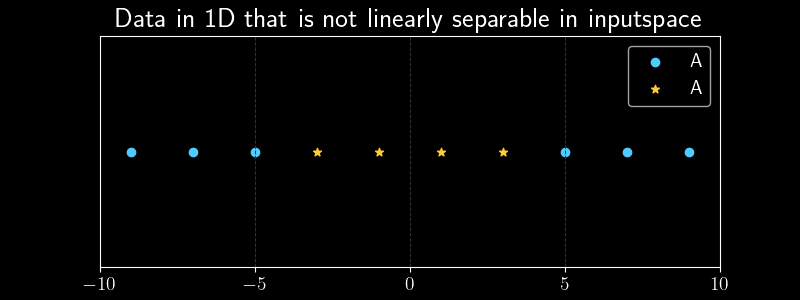

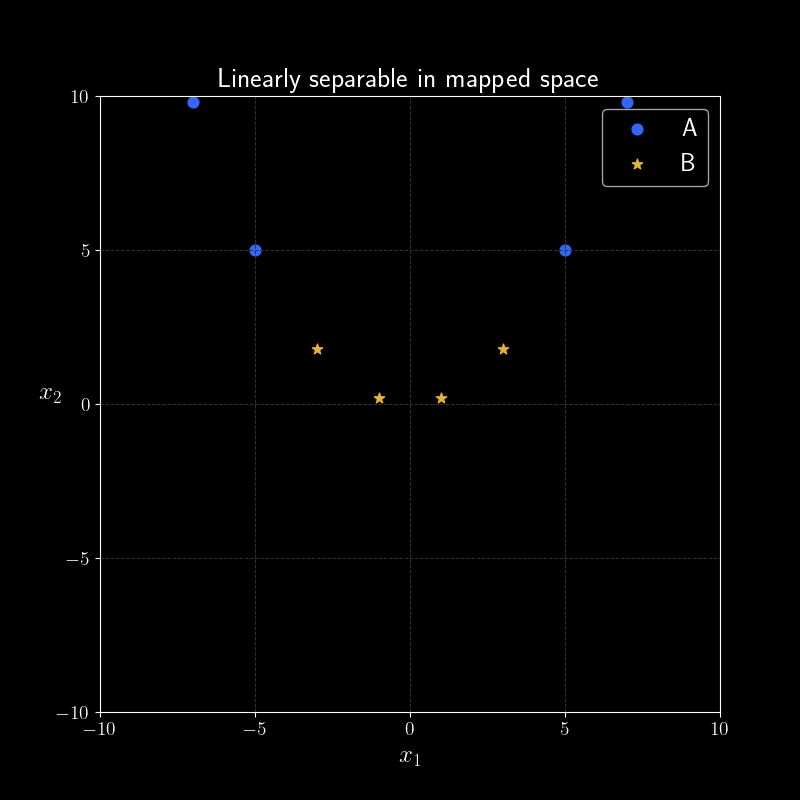

In [11]:
# Example non linear separable
A = np.array([-9,-7,-5,5,7,9])
B = np.array([-3,-1,1,3])
fname = "non_linear_1D.png"

plot_1d_scatter(A, B, fname)
display(IMG(filename=fname))

# mapped 
A_mapped = phi_map_1d_to_2d(A)
B_mapped = phi_map_1d_to_2d(B)
fname = "non_linear_1D_mapped.png"
plot_two_scatter(A_mapped, B_mapped, "Linearly separable in mapped space",fname)
display(IMG(filename=fname))

In [12]:
from sklearn.linear_model import Perceptron

def plot_perceptron( A,B,title, folder, rand_init):
    # get x1 and x2 values from A and B
    A_x1 = A[:,0]
    A_x2 = A[:,1]
    B_x1 = B[:,0]
    B_x2 = B[:,1]
    fsize = 18
    
    plt.figure(figsize=(8, 8))
    plt.xlim(-10,10)
    plt.ylim(-10,10)
    plt.xticks([-10,-5,0,5,10], fontsize = 14)
    plt.yticks([-10,-5,0,5,10], fontsize = 14)

    #--------------plot data ------------------------------------------
    plt.title(title, fontsize = fsize)
    plt.rc('text', usetex=True)
    plt.xlabel("$x_1$", fontsize = 18, rotation = 0)
    plt.ylabel("$x_2$", fontsize = 18, rotation = 0)
    plt.scatter(A_x1,A_x2, s = 60, color = nice_blue,  label="A")
    plt.scatter(np.mean(A_x1), np.mean(A_x2), s = 30, color = off_white)
    plt.scatter(B_x1,B_x2, s = 60, color = nice_orange, label="B", marker = "*")
    plt.scatter(np.mean(B_x1), np.mean(B_x2), s = 30, color = off_white, marker = "*")

    X = np.vstack((A, B))
    y = np.hstack((np.zeros(A.shape[0]), np.ones(B.shape[0])))
    per = Perceptron(early_stopping=False, max_iter = 500, random_state=rand_init)
    per.fit(X, y)
    xx, yy = np.meshgrid(np.arange(-10, 10, 0.02), np.arange(-10, 10, 0.02))
    Z = per.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z, colors="white", levels=[0.5], linestyles=['dashed'], linewidths = 3)
    plt.grid(color=(0.2,0.2,0.2), linestyle='--', linewidth=0.7)
    plt.legend( loc="lower left",fontsize = fsize)
    #plt.legend(loc= "upper right", fontsize = fsize)
    plt.savefig(folder)

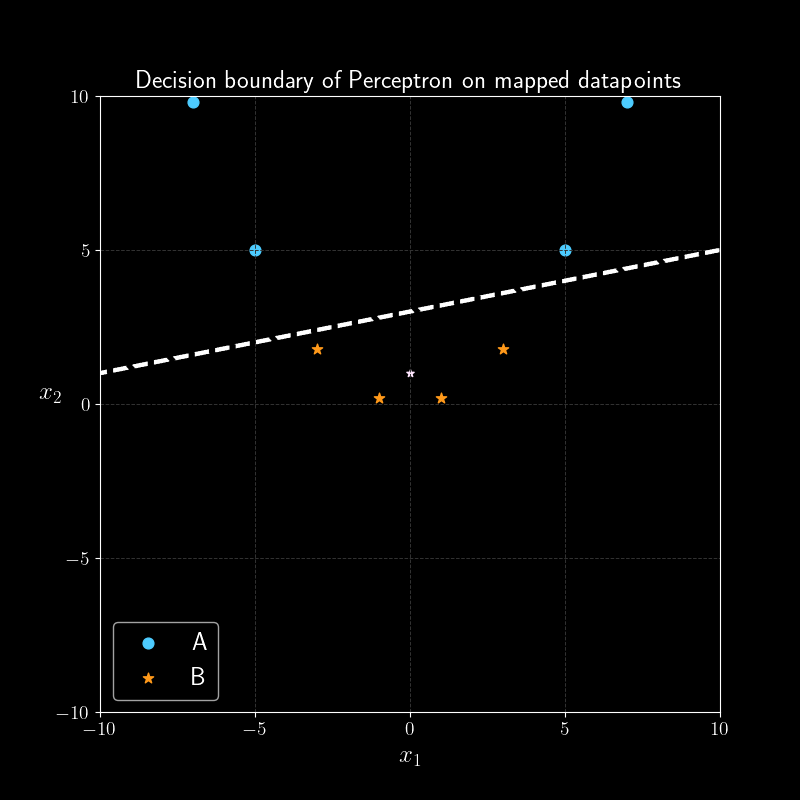

In [13]:
fname =  "non_linear_1D_mapped_perceptron.png"
plot_perceptron(A_mapped, B_mapped,"Decision boundary of Perceptron on mapped datapoints", fname,1)
display(IMG(filename=fname))


In [15]:
def phi_map_2d_to_3d(X):
    X = np.asarray(X)
    x1 = X[:, 0]
    x2 = X[:, 1]
    x3 = x1**2 + x2**2
    return np.column_stack([x1, x2, x3])

In [16]:
def plot_three_scatter(A, B, title, folder):
    plt.style.use('dark_background')
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')

    # extract coordinates
    Ax, Ay, Az = A[:,0], A[:,1], A[:,2]
    Bx, By, Bz = B[:,0], B[:,1], B[:,2]

    # plotting data
    ax.scatter(Ax, Ay, Az, s=30, color=(0.2,0.4,1), label="A")
    ax.scatter(Bx, By, Bz, s=40, color=(0.9,0.7,0.2), marker='*', label="B")

    # axis labels
    ax.set_xlabel(r"$x_1$", fontsize=16)
    ax.set_ylabel(r"$x_2$", fontsize=16)
    ax.set_zlabel(r"$x_3$", fontsize=16)
    ax.set_title(title, fontsize=19)

    # face style
    ax.xaxis.pane.set_facecolor(black)
    ax.yaxis.pane.set_facecolor(black)
    ax.zaxis.pane.set_facecolor(off_black)  
    # border style
    ax.xaxis.pane.set_edgecolor(black)
    ax.yaxis.pane.set_edgecolor(black)
    ax.zaxis.pane.set_edgecolor(off_black)
    # grid style
    ax.xaxis._axinfo["grid"]['color'] = (0.5,0.5,0.5)
    ax.yaxis._axinfo["grid"]['color'] = (0.5,0.5,0.5)
    ax.zaxis._axinfo["grid"]['color'] = (0.5,0.5,0.5)
   

    ax.legend(fontsize=14)
    plt.tight_layout()
    plt.savefig(folder)


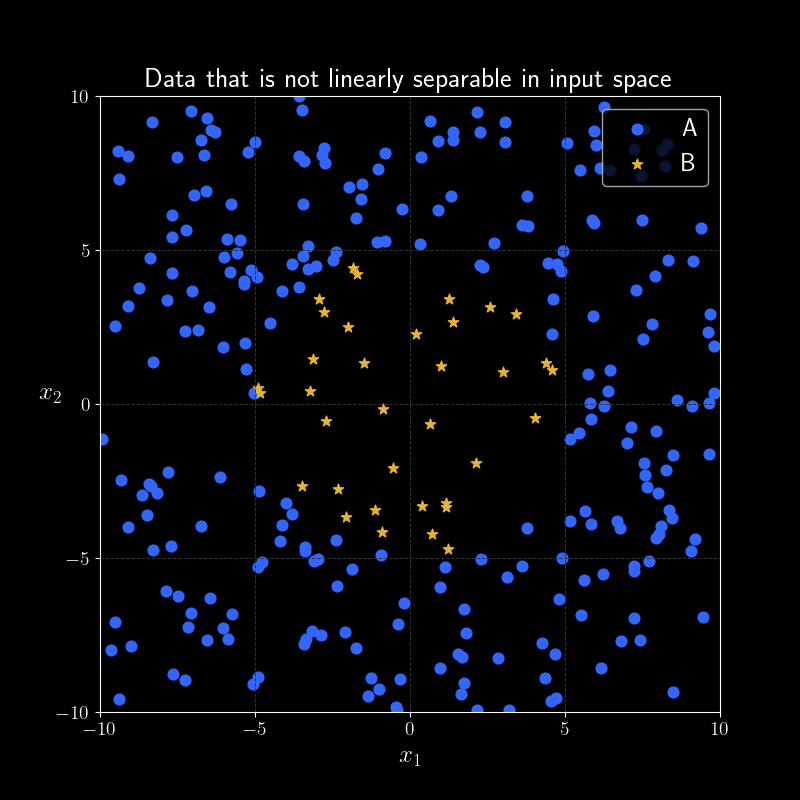

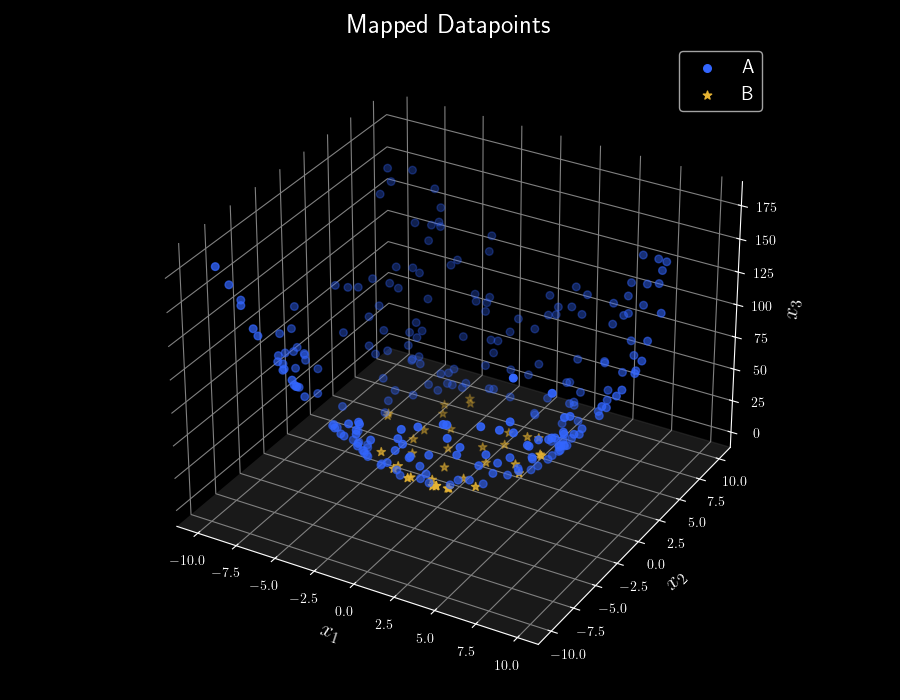

In [17]:
# generate non linearly separabe datapoints in 2D
N_A = 300 
N_B = 200
r = 5

batch = np.random.uniform(-10, 10, size=(N_A, 2))
mask = np.linalg.norm(batch, axis=1) >= r
A = batch[mask][:N_A]

batch = np.random.uniform(-10, 10, size=(N_B, 2))
mask = np.linalg.norm(batch, axis=1) < r
B = batch[mask][:N_B]

fname =  "non_linear_2D.png"
plot_two_scatter(A,B,"Data that is not linearly separable in input space",fname)
display(IMG(filename=fname))


fname =  "non_linear_2D_mapped.png"
A_mapped = phi_map_2d_to_3d(A)
B_mapped = phi_map_2d_to_3d(B)
plot_three_scatter(A_mapped, B_mapped, "Mapped Datapoints", fname)
display(IMG(filename=fname))


In [18]:
def plot_perceptron_3d(A, B, folder, rand_init=0):
    """
    Fit perceptron to 3D data and plot its separating plane.
    """

    plt.style.use('dark_background')
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')

    # extract coordinate arrays
    Ax, Ay, Az = A[:,0], A[:,1], A[:,2]
    Bx, By, Bz = B[:,0], B[:,1], B[:,2]

    # plot data
    ax.scatter(Ax, Ay, Az, s=30, color=(0.2,0.4,1), label="A")
    ax.scatter(Bx, By, Bz, s=40, color=(0.9,0.7,0.2), marker="*", label="B")

    # prepare data for perceptron
    X = np.vstack((A, B))
    y = np.hstack((np.zeros(A.shape[0]), np.ones(B.shape[0])))

    per = Perceptron(
        early_stopping=False,      # important for small datasets
        max_iter=2000,
        random_state=rand_init
    )
    per.fit(X, y)

    # plane parameters
    w = per.coef_[0]      # shape (3,)
    b = per.intercept_[0]

    # generate grid for the plane
    x_range = np.linspace(X[:,0].min(), X[:,0].max(), 50)
    y_range = np.linspace(X[:,1].min(), X[:,1].max(), 50)
    xx, yy = np.meshgrid(x_range, y_range)

    # linear plane: w1 x + w2 y + w3 z + b = 0
    if abs(w[2]) < 1e-12:
        # degenerate case: plane is vertical
        # skip drawing plane
        pass
    else:
        zz = -(w[0]*xx + w[1]*yy + b) / w[2]
        ax.plot_surface(xx, yy, zz, alpha=0.25, color="white", linewidth=0, antialiased=False)

    # labels and style
    ax.set_xlabel(r"$x_1$", fontsize=16)
    ax.set_ylabel(r"$x_2$", fontsize=16)
    ax.set_zlabel(r"$x_3$", fontsize=16)
    ax.set_title("Perceptron in Mapped 3D Space", fontsize=19)
    ax.legend(fontsize=14)

    # subtle grid
    ax.xaxis._axinfo["grid"]['color'] = (0.2,0.2,0.2,0.6)
    ax.yaxis._axinfo["grid"]['color'] = (0.2,0.2,0.2,0.6)
    ax.zaxis._axinfo["grid"]['color'] = (0.2,0.2,0.2,0.6)

    plt.tight_layout()
    plt.savefig(folder)

plot_perceptron_3d(A_mapped, B_mapped, "test.png")

In [19]:
import os
import matplotlib.pyplot as plt
import imageio
from mpl_toolkits.mplot3d import Axes3D

def make_rotating_2_class_3D_per_gif(A, B, gif_name="rotation.gif", folder="frames"):
    """
    Create 40 rotation frames of a 3D scatter plot and combine them into a GIF.

    A, B: arrays of shape (n, 3)
    gif_name: filename for output
    folder: directory in which images are stored
    """

    # create directory for frames
    os.makedirs(folder, exist_ok=True)

    # extract coordinates
    Ax, Ay, Az = A[:,0], A[:,1], A[:,2]
    Bx, By, Bz = B[:,0], B[:,1], B[:,2]

    


    filenames = []

    # generate frames
    for i in range(100):
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')

        plt.style.use('dark_background')

        ax.scatter(Ax, Ay, Az, s=30, color=nice_blue, edgecolor=(0.2,0.2,0.8))
        ax.scatter(Bx, By, Bz, s=40, color=nice_yellow, marker='*', edgecolor=(1,0.9,0.2))

        # prepare data for perceptron
        X = np.vstack((A, B))
        y = np.hstack((np.zeros(A.shape[0]), np.ones(B.shape[0])))
        
        per = Perceptron(
            early_stopping=False,      # important for small datasets
            max_iter=2000,
            random_state=1
        )
        per.fit(X, y)

        # plane parameters
        w = per.coef_[0]      # shape (3,)
        b = per.intercept_[0]

        # generate grid for the plane
        x_range = np.linspace(X[:,0].min(), X[:,0].max(), 10)  # fewer points
        y_range = np.linspace(X[:,1].min(), X[:,1].max(), 10)
        xx, yy = np.meshgrid(x_range, y_range)


        # linear plane: w1 x + w2 y + w3 z + b = 0
        if abs(w[2]) < 1e-12:
            # degenerate case: plane is vertical
            # skip drawing plane
            pass
        else:
            zz = -(w[0]*xx + w[1]*yy + b) / w[2]
            ax.plot_surface(xx, yy, zz, alpha=0.7, color=(0.3,0,0.3), linewidth=0.03, antialiased=False, edgecolor=(0.5,0.1,0.5))

        nice_green = (0.6,1.0,0.3)
        ax.set_xlabel(r"$x_1$", fontsize=14)
        ax.set_ylabel(r"$x_2$", fontsize=14, rotation = 90)
        ax.set_zlabel(r"$\varphi{[x_1, x_2]^\top}$", fontsize=14, color= (0.5,0.5,0.5), rotation = 0)
        zmin = min(Az.min(), Bz.min())
        zmax = max(Az.max(), Bz.max())
        m = max(abs(zmin), abs(zmax))
        ax.set_zlim(-m, m)

        # draw pole
        #ax.plot([0,0], [0,0], [-m, m], color="white", linewidth=1.5)


        # face style
        ax.xaxis.pane.set_facecolor(black)
        ax.yaxis.pane.set_facecolor(black)
        ax.zaxis.pane.set_facecolor(off_black)  
        # border style
        ax.xaxis.pane.set_edgecolor(black)
        ax.yaxis.pane.set_edgecolor(black)
        ax.zaxis.pane.set_edgecolor(off_black)
        # grid style
        ax.xaxis._axinfo["grid"]['color'] = (0.5,0.5,0.5)
        ax.yaxis._axinfo["grid"]['color'] = (0.5,0.5,0.5)
        ax.zaxis._axinfo["grid"]['color'] = (0.5,0.5,0.5)

        ax.zaxis.line.set_color('black') 
        # make the z-axis numbers gray
        ax.tick_params(axis='z', colors='gray')   # works for 3D axes


        # rotate view angle
        ax.view_init(elev=30, azim=1*i)


        # save frame
        fname = f"{folder}/frame_{i:03d}.png"
        plt.savefig(fname, dpi=120)
        plt.close(fig)
        filenames.append(fname)

    # make GIF
    with imageio.get_writer(gif_name, mode='I', duration=0.04, loop=0) as writer:
        for fname in filenames:
            writer.append_data(imageio.imread(fname))

# generate non linearly separabe datapoints in 2D
N_A = 300 
N_B = 200
r = 5

batch = np.random.uniform(-10, 10, size=(N_A, 2))
mask = np.linalg.norm(batch, axis=1) >= r
A = batch[mask][:N_A]

batch = np.random.uniform(-10, 10, size=(N_B, 2))
mask = np.linalg.norm(batch, axis=1) < r
B = batch[mask][:N_B]

A3 = phi_map_2d_to_3d(A)
B3 = phi_map_2d_to_3d(B)
fname =  "non_linear_2D_mapped_perceptron.gif"
make_rotating_2_class_3D_per_gif(A3, B3, 
gif_name=fname)


/var/folders/0q/699d2ftx6y1g94yr56ph98h40000gn/T/ipykernel_4500/3184647823.py:111: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(fname))


In [20]:
def wireframe3d_we_illusion_b(X,Y,Z, s, title):
    fig = plt.figure(figsize=(16, 16), dpi=300)
    ax = fig.add_subplot(111, projection='3d')
    
    surf = ax.plot_surface(X, Y, Z, cmap='binary_r', edgecolor='none', alpha=0.9)

    ax.plot_wireframe(X, Y, Z, color='black', linewidth=1.9* s, alpha=1)
    ax.plot_wireframe(X, Y, Z, color='grey', linewidth=0.6* s, alpha=1)

    elev = 20
    azim = 110
    ax.view_init(elev=elev, azim=azim)
    ax.set_zlim(-2, 4)
    ax.zaxis.set_major_locator(LinearLocator(10))
    ax.zaxis.set_major_formatter('{x:.02f}')
    ax.set_axis_off()
    plt.tight_layout()

    plt.savefig(f"test.png", transparent=True, bbox_inches='tight')

    plt.show()

n = 10
domain = 1.5
X = np.linspace(-domain,domain,n)
Y = np.linspace(-domain,domain,n)
X, Y = np.meshgrid(X, Y)
def f(X,Y):
    return -(X**2 + Y**2)

Z = f(X,Y)

wireframe3d_we_illusion_b(X,Y,Z,1,"")

/var/folders/0q/699d2ftx6y1g94yr56ph98h40000gn/T/ipykernel_4500/2178621213.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [21]:
# takes long
def make_rotating_2_class_3D_gif(A, B, gif_name="rotation.gif", folder="frames"):

    # create directory for frames
    os.makedirs(folder, exist_ok=True)

    # extract coordinates
    Ax, Ay, Az = A[:,0], A[:,1], A[:,2]
    Bx, By, Bz = B[:,0], B[:,1], B[:,2]

    filenames = []

    # generate frames
    for i in range(360):
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')

        plt.style.use('dark_background')

        ax.scatter(Ax, Ay, Az, s=30, color=nice_blue, edgecolor=(0.2,0.2,0.8))
        ax.scatter(Bx, By, Bz, s=40, color=nice_orange, marker='*', edgecolor=nice_yellow)
        nice_green = (0.6,1.0,0.3)
        ax.set_xlabel(r"$x_1$", fontsize=14)
        ax.set_ylabel(r"$x_2$", fontsize=14, rotation = 90)
        ax.set_zlabel(r"$\varphi{[x_1, x_2]^\top}$", fontsize=14, color= (0.5,0.5,0.5), rotation = 0)
        zmin = min(Az.min(), Bz.min())
        zmax = max(Az.max(), Bz.max())
        m = max(abs(zmin), abs(zmax))
        ax.set_zlim(-m, m)

        # draw pole
        #ax.plot([0,0], [0,0], [-m, m], color="white", linewidth=1.5)


        # face style
        ax.xaxis.pane.set_facecolor(black)
        ax.yaxis.pane.set_facecolor(black)
        ax.zaxis.pane.set_facecolor(off_black)  
        # border style
        ax.xaxis.pane.set_edgecolor(black)
        ax.yaxis.pane.set_edgecolor(black)
        ax.zaxis.pane.set_edgecolor(off_black)
        # grid style
        ax.xaxis._axinfo["grid"]['color'] = (0.5,0.5,0.5)
        ax.yaxis._axinfo["grid"]['color'] = (0.5,0.5,0.5)
        ax.zaxis._axinfo["grid"]['color'] = (0.5,0.5,0.5)

        ax.zaxis.line.set_color('black') 
        # make the z-axis numbers gray
        ax.tick_params(axis='z', colors='gray')   # works for 3D axes


        # rotate view angle
        ax.view_init(elev=30, azim=0.5*i)


        # save frame
        fname = f"{folder}/frame_{i:03d}.png"
        plt.savefig(fname, dpi=120)
        plt.close(fig)
        filenames.append(fname)

    # make GIF
    with imageio.get_writer(gif_name, mode='I', duration=0.04, loop=0) as writer:
        for fname in filenames:
            writer.append_data(imageio.imread(fname))

# generate non linearly separabe datapoints in 2D
N_A = 300 
N_B = 200
r = 5

batch = np.random.uniform(-10, 10, size=(N_A, 2))
mask = np.linalg.norm(batch, axis=1) >= r
A = batch[mask][:N_A]

batch = np.random.uniform(-10, 10, size=(N_B, 2))
mask = np.linalg.norm(batch, axis=1) < r
B = batch[mask][:N_B]

A3 = phi_map_2d_to_3d(A)
B3 = phi_map_2d_to_3d(B)
fname =  "non_linear_2D_mapped.gif"

make_rotating_2_class_3D_gif(A3, B3, gif_name=fname)


/var/folders/0q/699d2ftx6y1g94yr56ph98h40000gn/T/ipykernel_4500/2082262757.py:65: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(fname))


In [22]:
def make_falling_2_class_3D_gif(
        A, B, 
        gif_name="falling.gif", 
        folder="frames", 
        n_frames=100, 
        rotation_factor=0.25,  # fraction of full 360° rotation per frame
        reverse=False           # True: points rise back up
    ):
    import os, imageio
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    
    os.makedirs(folder, exist_ok=True)

    Ax, Ay, Az = A[:,0], A[:,1], A[:,2]
    Bx, By, Bz = B[:,0], B[:,1], B[:,2]

    filenames = []

    # define z start and end
    zA_start, zA_end = Az.copy(), np.zeros_like(Az)
    zB_start, zB_end = Bz.copy(), np.zeros_like(Bz)

    if reverse:
        zA_start, zA_end = zA_end, zA_start
        zB_start, zB_end = zB_end, zB_start

    for i in range(n_frames):
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111, projection='3d')
        plt.style.use('dark_background')

        # falling faster: t runs from 0 to 1 in first half of frames
        t = min(i / (n_frames//2), 1.0)

        Az_interp = (1-t)*zA_start + t*zA_end
        Bz_interp = (1-t)*zB_start + t*zB_end

        ax.scatter(Ax, Ay, Az_interp, s=30, color=nice_blue, edgecolor=(0.2,0.2,0.8))
        ax.scatter(Bx, By, Bz_interp, s=40, color=nice_orange, marker='*', edgecolor=nice_yellow)

        # axes labels
        ax.set_xlabel(r"$x_1$", fontsize=14)
        ax.set_ylabel(r"$x_2$", fontsize=14, rotation=90)
        ax.set_zlabel(r"$x_3$", fontsize=14, color=(0.5,0.5,0.5), rotation=0)

        # fixed limits
        xlim = (min(Ax.min(), Bx.min()), max(Ax.max(), Bx.max()))
        ylim = (min(Ay.min(), By.min()), max(Ay.max(), By.max()))
        zlim = (0, max(Az.max(), Bz.max()))
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_zlim(*zlim)

        # dark mode styling
        black = (0,0,0)
        off_black = (0.05,0.05,0.05)
        ax.xaxis.pane.set_facecolor(black)
        ax.yaxis.pane.set_facecolor(black)
        ax.zaxis.pane.set_facecolor(off_black)  
        ax.xaxis.pane.set_edgecolor(black)
        ax.yaxis.pane.set_edgecolor(black)
        ax.zaxis.pane.set_edgecolor(off_black)
        ax.xaxis._axinfo["grid"]['color'] = (0.5,0.5,0.5)
        ax.yaxis._axinfo["grid"]['color'] = (0.5,0.5,0.5)
        ax.zaxis._axinfo["grid"]['color'] = (0.5,0.5,0.5)
        ax.tick_params(axis='z', colors='gray')
        ax.zaxis.line.set_color('black') 

        # slower rotation: multiply i by rotation_factor*360°
        azim = rotation_factor * 360 * i / n_frames
        ax.view_init(elev=30, azim=azim)

        # save frame
        fname = f"{folder}/frame_{i:03d}.png"
        plt.savefig(fname, dpi=120)
        plt.close(fig)
        filenames.append(fname)

    # make GIF
    with imageio.get_writer(gif_name, mode='I', duration=0.04, loop=0) as writer:
        for fname in filenames:
            writer.append_data(imageio.imread(fname))


A3 = phi_map_2d_to_3d(A)
B3 = phi_map_2d_to_3d(B)
make_falling_2_class_3D_gif(A3, B3, gif_name="falling.gif")

/var/folders/0q/699d2ftx6y1g94yr56ph98h40000gn/T/ipykernel_4500/3410253219.py:83: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(fname))


Kernel ridge regression with gaussian kernel

In [24]:
# function used as k function
def rbf_kernel_function(x_i, x_j, sigma):
    return pow(np.exp(1), -((x_i - x_j)**2 / (2 * sigma**2)))

# Calculate Gram Matrix
def calc_K(X,sigma):
    K = np.zeros((n,n))
    for i in range(0,n):
        for j in range(0,n):
            K[i][j] =  rbf_kernel_function(X[i], X[j], sigma)
    return K

# Calculate alpha
def calc_alpha(K, lamb):
    return np.linalg.inv(K + (lamb * np.identity(n))) @ Y.T

# save parameters in a matrix
def calc_comb(sigmas, lambdas):
    para = len(sigmas)
    
    comb = np.zeros((para,para,n))
    for i in range(0,para):
        for j in range(0,para):
            comb[i][j] = calc_alpha(calc_K(X, sigmas[i]), lambdas[j])
    return comb

# this function is f{hat} and will be plotted as a fit in the plot
def pred_func(x,sigma, alpha):
    res = 0
    for i in range(len(X)):
        res = res + alpha[i] * rbf_kernel_function(X[i], x,sigma)
    return res

In [28]:
# datapoints
X = np.linspace(-10,10,20)
n = X.shape[0]
print(n)
noise = np.random.normal(0, 1, n) * 1
Y = np.sin(X) * 7 + noise

# parameters
sigmas = np.array([0.01,0.1,1,10])
lambdas = np.array([0.01,0.1,1,10])

comb_matrix = calc_comb(sigmas, lambdas)

X_lin = np.linspace(-10, 10, 1500, dtype=float)
Y_pred  = np.zeros(X_lin.shape)

n = 0
for k in range(0,len(sigmas)):
    for i in range(0,len(sigmas)):

        for j in range(len(X_lin)):
            alpha = comb_matrix[k][i]
            Y_pred[j] = pred_func(X_lin[j], sigmas[k], alpha)
        n = n + 1
        plot_function_and_datapoints(X_lin,Y_pred, X, Y,f"test",f"ex1/plot_{k}_{i}.png")
        plot_function_and_datapoints(X_lin,Y_pred, X, Y,"test","test.png")

collage = create_collage("ex1/", 4, 4, 2, "test.png")
collage.save("lambda_vs_sigma_dots_4_ver2.png")

20


In [35]:
def plot_mse_grid(errors, lams, degrees,title,fname):
        plt.figure(figsize=(8,5)) # to clear previous plot
        plt.rc('text', usetex=True)
        plt.xlabel("$Log_{10}(\lambda)$", fontsize = 18, rotation = 0)
        plt.ylabel("Degree $d$", fontsize = 18, rotation = 90)
        plt.xticks(fontsize = 14)
        plt.yticks(fontsize = 14)
        plt.title(title, fontsize = 20)
        plt.grid(color=(0,0,0), linestyle='--', linewidth=0.7, zorder = 1)

        im = plt.imshow(errors, aspect='auto', origin='lower',
                extent=[np.log10(lams[0]), np.log10(lams[-1]), degrees.start, degrees.stop],
                norm=colors.LogNorm(vmin=0.3, vmax=1000),
                cmap="bone") 
        #norm=colors.LogNorm(vmin=errors.min()+1e-8, vmax=errors.max()))  #avoid log(0)

        cbar = plt.colorbar(im, orientation='vertical', shrink=0.8, pad=0.02)
        cbar.set_label("MSE (log scale)", fontsize=14)
        plt.savefig(fname)


n = 17
var_noise = 3
degrees = range(0, n)
lams = np.logspace(-6, 3, 18)

# true
w_true = np.array([0.15, 0, -9])
poly_func = np.poly1d(w_true)
X_m_train = np.linspace(-10, 10, n)
Y_m_train = poly_func(X_m_train) + np.random.normal(0, var_noise, n)
# scaling
a, b = X_m_train.min(), X_m_train.max()
xm = 2*(X_m_train - a)/(b - a) - 1

# performance grid on train
errors = np.zeros((len(degrees), len(lams)))
for i, d in enumerate(degrees):
    Phi = chebvander(xm, d)
    for j, lam in enumerate(lams):
        A = Phi.T @ Phi + lam * np.eye(d+1)
        w = np.linalg.solve(A, Phi.T @ Y_m_train)
        Y_hat = Phi @ w
        errors[i, j] = np.mean((Y_hat - Y_m_train)**2)

fname = "test.png"
plot_mse_grid(errors, lams, degrees,"Grid of $\lambda$ and $d$ on train data",fname)

# grid search on test
errors = np.zeros((len(degrees), len(lams)))
test_n = 500
X_m_test = np.linspace(-10, 10, test_n)
xm_test = 2*(X_m_test - a)/(b - a) - 1
Y_m_test = poly_func(X_m_test) + np.random.normal(0, var_noise, test_n)

for i, d in enumerate(degrees):
    Phi_train = chebvander(xm, d)
    for j, lam in enumerate(lams):
        # fit on training
        A = Phi_train.T @ Phi_train + lam * np.eye(d+1)
        w = np.linalg.solve(A, Phi_train.T @ Y_m_train)
        # predict on test
        Phi_test = chebvander(xm_test, d)
        Y_hat_test = Phi_test @ w
        errors[i, j] = np.mean((Y_hat_test - Y_m_test)**2)

fname = "test.png"
plot_mse_grid(errors, lams, degrees,"Grid of $\lambda$ and $d$ on test data",fname)


In [36]:
# RBF kernel function
def rbf_kernel(x1, x2, sigma):
    return np.exp(-((x1 - x2)**2) / (2 * sigma**2))

# Plotting function 
def plot_mse_grid(errors, lams, sigmas, title, fname):
    plt.figure(figsize=(8,5))
    plt.rc('text', usetex=True)
    plt.xlabel("$\log_{10}(\lambda)$", fontsize=18)
    plt.ylabel("$\sigma$", fontsize=18)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.title(title, fontsize=20)
    plt.grid(color=(0,0,0), linestyle='--', linewidth=0.7, zorder=1)

    im = plt.imshow(errors, aspect='auto', origin='lower',
                    extent=[np.log10(lams[0]), np.log10(lams[-1]), sigmas[0], sigmas[-1]],
                    norm=colors.LogNorm(vmin=max(0.3, errors.min()), vmax=max(1e3, errors.max())),
                    cmap="bone")

    cbar = plt.colorbar(im, orientation='vertical', shrink=0.8, pad=0.02)
    cbar.set_label("MSE (log scale)", fontsize=14)
    plt.savefig(fname)
    plt.close()

n_train = 17
var_noise = 3
X_train = np.linspace(-10, 10, n_train)
Y_train = 7 * np.sin(X_train) + np.random.normal(0, var_noise, n_train)

X_test = np.linspace(-10, 10, 500)
Y_test = 7 * np.sin(X_test) + np.random.normal(0, var_noise, 500)

# Grid of parameters
lams = np.logspace(-6, 3, 18)
sigmas = np.logspace(-2, 1, 18)

errors_train = np.zeros((len(sigmas), len(lams)))
errors_test = np.zeros((len(sigmas), len(lams)))

# Grid search
for i, sigma in enumerate(sigmas):
    # Compute Gram matrix on train
    K_train = np.array([[rbf_kernel(xi, xj, sigma) for xj in X_train] for xi in X_train])
    for j, lam in enumerate(lams):
        alpha = np.linalg.solve(K_train + lam * np.eye(n_train), Y_train)
        Y_hat_train = K_train @ alpha
        errors_train[i,j] = np.mean((Y_hat_train - Y_train)**2)

        # Test prediction
        K_test = np.array([[rbf_kernel(xi, xj, sigma) for xj in X_train] for xi in X_test])
        Y_hat_test = K_test @ alpha
        errors_test[i,j] = np.mean((Y_hat_test - Y_test)**2)

# Plot results
plot_mse_grid(errors_train, lams, sigmas, "Train MSE grid over lambda and sigma", "train_mse.png")
plot_mse_grid(errors_test, lams, sigmas, "Test MSE grid over lambda and sigma", "test_mse.png")